In [1]:
##########################################
# 0. Install Dependencies
##########################################
!pip install -q opencv-python

##########################################
# 1. Imports
##########################################
import os
import cv2
import numpy as np
import torch
import torchvision
from torch.utils.data import random_split, DataLoader
import torchvision.models as models
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision.datasets import ImageFolder
import torchvision.transforms as transforms
from torch.optim.lr_scheduler import CosineAnnealingLR

In [2]:
##########################################
# 2. BilateralFilterTransform
##########################################
class BilateralFilterTransform:
    """
    A custom transform applying a mild bilateral filter
    to reduce noise while preserving edges.
    """
    def __init__(self, d=3, sigmaColor=50, sigmaSpace=50):
        """
        d: Diameter of each pixel neighborhood (3 is small/light).
        sigmaColor: Filter sigma in color space.
        sigmaSpace: Filter sigma in coordinate space.
        """
        self.d = d
        self.sigmaColor = sigmaColor
        self.sigmaSpace = sigmaSpace

    def __call__(self, pil_img):
        """
        pil_img: a PIL image from the dataset.
        Returns a PIL image after applying bilateral filtering.
        """
        # Convert PIL -> NumPy -> OpenCV
        img_np = np.array(pil_img)

        if len(img_np.shape) == 2:
            # Grayscale
            filtered = cv2.bilateralFilter(img_np, self.d, self.sigmaColor, self.sigmaSpace)
        else:
            # Color image
            img_bgr = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)
            filtered_bgr = cv2.bilateralFilter(img_bgr, self.d, self.sigmaColor, self.sigmaSpace)
            filtered = cv2.cvtColor(filtered_bgr, cv2.COLOR_BGR2RGB)

        # Convert back to PIL
        return transforms.functional.to_pil_image(filtered)


In [3]:
##########################################
# 3. Data Extraction (Google Drive)
##########################################
import os

# Pointing directly to your custom Drive dataset
data_path = '/content/drive/MyDrive/CAPSTONE_CNN'

# List categories to confirm connection
if os.path.exists(data_path):
    categories = os.listdir(data_path)
    print("Categories in dataset:", categories)
else:
    print(f"Directory '{data_path}' not found. Please make sure Google Drive is mounted and the path is correct.")

Directory '/content/drive/MyDrive/CAPSTONE_CNN' not found. Please make sure Google Drive is mounted and the path is correct.


In [4]:
##########################################
# 4. Data Augmentation & Dataset
##########################################
# We'll add bilateral filtering only to training transforms.
train_transforms = transforms.Compose([
    BilateralFilterTransform(d=3, sigmaColor=50, sigmaSpace=50),  # mild bilateral filter
    transforms.Resize((256,256)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


In [6]:
# For validation & test, no random transforms, no bilateral filtering
val_test_transforms = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Ensure Google Drive is mounted before loading the dataset
if not os.path.exists('/content/drive'):
    from google.colab import drive
    print("Google Drive not found. Mounting now...")
    drive.mount('/content/drive')

# Load dataset & split
if os.path.exists(data_path):
    full_dataset = ImageFolder(data_path)
    class_names = full_dataset.classes
    num_classes = len(class_names)
    print("Classes:", class_names)
else:
    raise FileNotFoundError(f"The directory '{data_path}' still does not exist. Please check that the path in Google Drive is spelled correctly.")

Google Drive not found. Mounting now...
Mounted at /content/drive
Classes: ['test', 'train']


In [8]:
seed = 42
torch.manual_seed(seed)

# Dynamically calculate split sizes based on the actual dataset size
total_size = len(full_dataset)
train_size = int(0.8 * total_size)
val_size = int(0.1 * total_size)
test_size = total_size - train_size - val_size

print(f"Total images: {total_size} (Train: {train_size}, Val: {val_size}, Test: {test_size})")
train_set, val_set, test_set = random_split(full_dataset, [train_size, val_size, test_size])

train_set.dataset.transform = train_transforms
val_set.dataset.transform = val_test_transforms
test_set.dataset.transform = val_test_transforms

batch_size = 32
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_set, batch_size=batch_size*2, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_set, batch_size=batch_size*2, shuffle=False, num_workers=2, pin_memory=True)

Total images: 2751 (Train: 2200, Val: 275, Test: 276)


Sample batch from training set (with BilateralFilter):


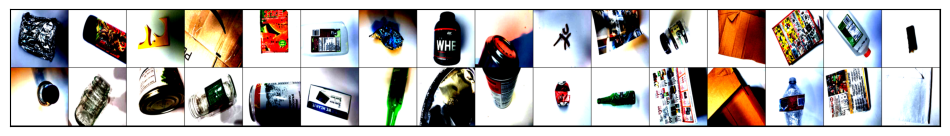

In [9]:
def display_batch(dl):
    for imgs, lbls in dl:
        fig, ax = plt.subplots(figsize=(12, 6))
        ax.set_xticks([])
        ax.set_yticks([])
        ax.imshow(torchvision.utils.make_grid(imgs, nrow=16).permute(1,2,0))
        plt.show()
        break

print("Sample batch from training set (with BilateralFilter):")
display_batch(train_loader)

In [10]:
##########################################
# 5. Define a Simple ResNet50 Model
##########################################
class ResNet50Modified(nn.Module):
    def __init__(self, num_classes):
        super(ResNet50Modified, self).__init__()
        self.network = models.resnet50(weights="IMAGENET1K_V2")

        # Replace final FC layers
        num_ftrs = self.network.fc.in_features
        self.network.fc = nn.Sequential(
            nn.Linear(num_ftrs, 500),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(500, 200),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(200, num_classes)
        )

    def forward(self, x):
        return self.network(x)

def freeze_layers(model, freeze_until=0):
    """
    freeze_until=0 => unfreeze all layers
    freeze_until=6 => freeze more layers
    etc.
    """
    child_counter = 0
    for child in model.network.children():
        child_counter += 1
        if child_counter < freeze_until:
            for param in child.parameters():
                param.requires_grad = False
    return model

In [11]:
##########################################
# 6. Training & Validation
##########################################
def train_model(epochs, model, train_loader, val_loader, optimizer, scheduler, criterion, device):
    history = []
    for epoch in range(epochs):
        model.train()
        train_losses = []
        train_correct = 0
        total_train = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5)
            optimizer.step()
            train_losses.append(loss.item())

            _, preds = torch.max(outputs, dim=1)
            train_correct += (preds == labels).sum().item()
            total_train += labels.size(0)

        train_loss_avg = sum(train_losses) / len(train_losses)
        train_acc = train_correct / total_train

        # Validation
        model.eval()
        val_losses = []
        val_correct = 0
        total_val = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                val_loss = criterion(outputs, labels)
                val_losses.append(val_loss.item())

                _, preds = torch.max(outputs, dim=1)
                val_correct += (preds == labels).sum().item()
                total_val += labels.size(0)

        val_loss_avg = sum(val_losses) / len(val_losses)
        val_acc = val_correct / total_val

        scheduler.step()  # CosineAnnealingLR typically updates each epoch

        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {train_loss_avg:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss_avg:.4f} | Val Acc: {val_acc:.4f}")

        history.append({
            'epoch': epoch+1,
            'train_loss': train_loss_avg,
            'train_acc': train_acc,
            'val_loss': val_loss_avg,
            'val_acc': val_acc
        })
    return history

In [12]:
##########################################
# 7. Main: Instantiate & Train
##########################################
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ResNet50Modified(num_classes=num_classes).to(device)

# Optionally freeze or unfreeze layers
# If your dataset is large, unfreeze all (freeze_until=0).
# If smaller, freeze more (like freeze_until=6).
model = freeze_layers(model, freeze_until=0)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=30, eta_min=1e-6)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 153MB/s]


Epoch 1/20 | Train Loss: 0.5635 | Train Acc: 0.7918 | Val Loss: 0.5635 | Val Acc: 0.7927
Epoch 2/20 | Train Loss: 0.4722 | Train Acc: 0.7918 | Val Loss: 0.6011 | Val Acc: 0.7927
Epoch 3/20 | Train Loss: 0.3694 | Train Acc: 0.8577 | Val Loss: 0.5951 | Val Acc: 0.7673
Epoch 4/20 | Train Loss: 0.2807 | Train Acc: 0.9650 | Val Loss: 0.6985 | Val Acc: 0.6691
Epoch 5/20 | Train Loss: 0.2555 | Train Acc: 0.9786 | Val Loss: 0.6492 | Val Acc: 0.7636
Epoch 6/20 | Train Loss: 0.2390 | Train Acc: 0.9818 | Val Loss: 0.6393 | Val Acc: 0.7600
Epoch 7/20 | Train Loss: 0.2235 | Train Acc: 0.9927 | Val Loss: 0.6838 | Val Acc: 0.7709
Epoch 8/20 | Train Loss: 0.2171 | Train Acc: 0.9936 | Val Loss: 0.6362 | Val Acc: 0.7818
Epoch 9/20 | Train Loss: 0.2117 | Train Acc: 0.9964 | Val Loss: 0.6101 | Val Acc: 0.7782
Epoch 10/20 | Train Loss: 0.2097 | Train Acc: 0.9968 | Val Loss: 0.5998 | Val Acc: 0.7855
Epoch 11/20 | Train Loss: 0.2079 | Train Acc: 0.9968 | Val Loss: 0.6285 | Val Acc: 0.7673
Epoch 12/20 | Train

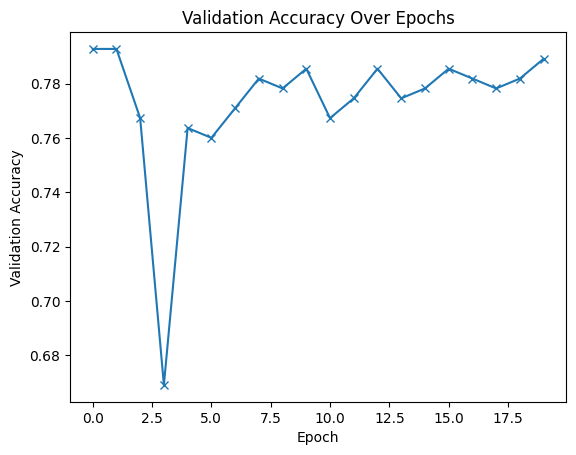

In [13]:
num_epochs = 20
history = train_model(num_epochs, model, train_loader, val_loader, optimizer, scheduler, criterion, device)

# Plot Accuracy
plt.plot([h['val_acc'] for h in history], '-x')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy Over Epochs')
plt.show()

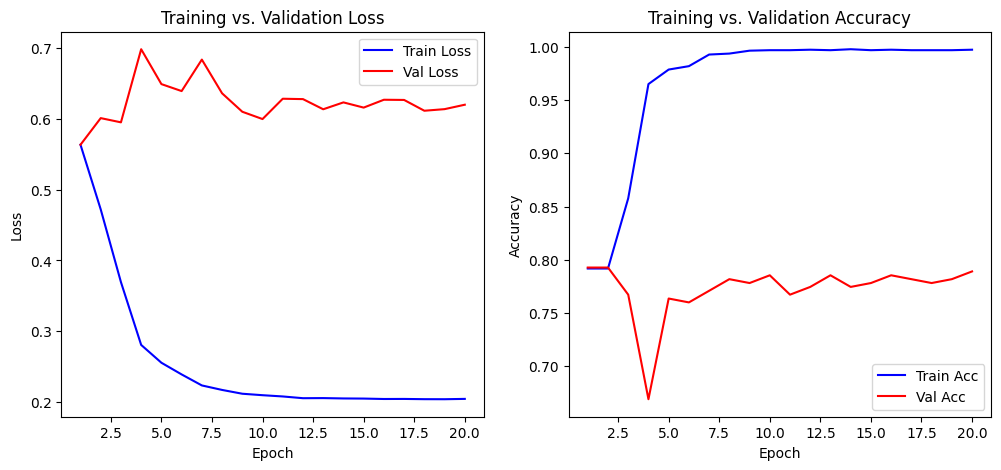

In [14]:
##########################################
# 7. Plot Training Curves
##########################################
epochs_list = [h['epoch'] for h in history]
train_acc_list = [h['train_acc'] for h in history]
val_acc_list = [h['val_acc'] for h in history]
train_loss_list = [h['train_loss'] for h in history]
val_loss_list = [h['val_loss'] for h in history]

plt.figure(figsize=(12,5))

# Loss curves
plt.subplot(1,2,1)
plt.plot(epochs_list, train_loss_list, 'b-', label='Train Loss')
plt.plot(epochs_list, val_loss_list, 'r-', label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs. Validation Loss')
plt.legend()

# Accuracy curves
plt.subplot(1,2,2)
plt.plot(epochs_list, train_acc_list, 'b-', label='Train Acc')
plt.plot(epochs_list, val_acc_list, 'r-', label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs. Validation Accuracy')
plt.legend()

plt.show()

In [15]:
# After training completes
MODEL_PATH = "resnet50_modified.pth"

# Save only the model's state_dict (recommended best practice)
torch.save(model.state_dict(), MODEL_PATH)

print(f"Model saved to {MODEL_PATH}")


Model saved to resnet50_modified.pth


In [16]:
# 8. Evaluate on Test Set
##########################################
model.eval()
test_correct = 0
total_test = 0
preds_list = []
labels_list = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, dim=1)
        test_correct += (preds == labels).sum().item()
        total_test += labels.size(0)

        # Collect for confusion matrix
        preds_list.extend(preds.cpu().numpy())
        labels_list.extend(labels.cpu().numpy())

test_acc = test_correct / total_test
print(f"Test Accuracy: {test_acc:.4f}")


Test Accuracy: 0.7971


In [17]:
# For metrics & plots
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns


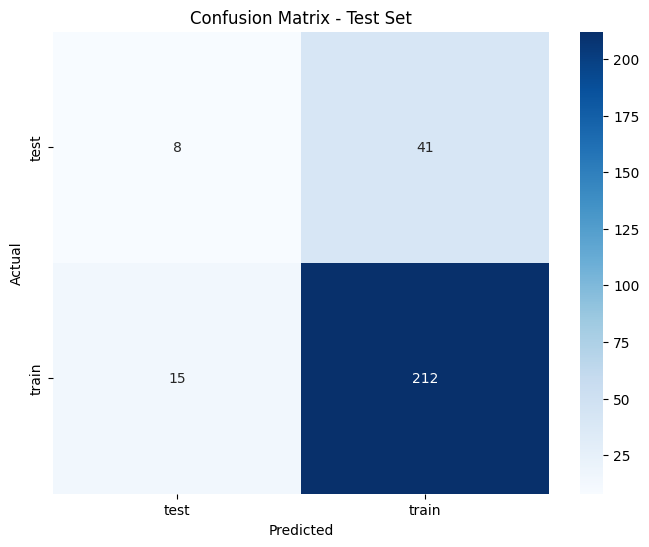

Classification Report:
              precision    recall  f1-score   support

        test       0.35      0.16      0.22        49
       train       0.84      0.93      0.88       227

    accuracy                           0.80       276
   macro avg       0.59      0.55      0.55       276
weighted avg       0.75      0.80      0.77       276



In [18]:
##########################################
# 9. Confusion Matrix & Classification Report
##########################################
cm = confusion_matrix(labels_list, preds_list)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix - Test Set")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("Classification Report:")
print(classification_report(labels_list, preds_list, target_names=class_names))


In [19]:
!pip install captum shap


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 15.3 MB/s eta 0:00:00


In [20]:
##########################################
# XAI Add-On: Grad-CAM & SHAP
##########################################

import shap
from captum.attr import LayerGradCam
import torch.nn.functional as F
import cv2

In [21]:

##########################################
# 1. Grad-CAM with Captum
##########################################
# We'll pick the last convolutional layer in layer4
# For ResNet50, often it's layer4[-1].conv3
last_conv_layer = model.network.layer4[-1].conv3

gradcam = LayerGradCam(model, last_conv_layer)

def show_gradcam(model, image, label_idx, class_names):
    """
    Generates Grad-CAM heatmap for a single image & label,
    displays the original & overlay side-by-side.
    """
    model.eval()
    image_batch = image.unsqueeze(0).to(device)
    attributions = gradcam.attribute(image_batch, target=label_idx)

    # Convert attributions to a heatmap
    grad = attributions.squeeze().detach().cpu().numpy()
    grad = np.maximum(grad, 0)
    grad /= (grad.max() + 1e-8)

    # Resize heatmap to match original image
    heatmap = cv2.resize(grad, (image.shape[2], image.shape[1]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    # Original image to [0..1] range for blending
    img_np = image.permute(1,2,0).cpu().numpy()
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())
    img_np = np.uint8(255 * img_np)

    overlay = cv2.addWeighted(img_np, 0.6, heatmap, 0.4, 0)

    # Show images
    fig, ax = plt.subplots(1,2, figsize=(10,5))
    ax[0].imshow(img_np)
    ax[0].set_title(f"Original Image\n(Label: {class_names[label_idx]})")
    ax[0].axis('off')
    ax[1].imshow(overlay)
    ax[1].set_title("Grad-CAM Overlay")
    ax[1].axis('off')
    plt.show()


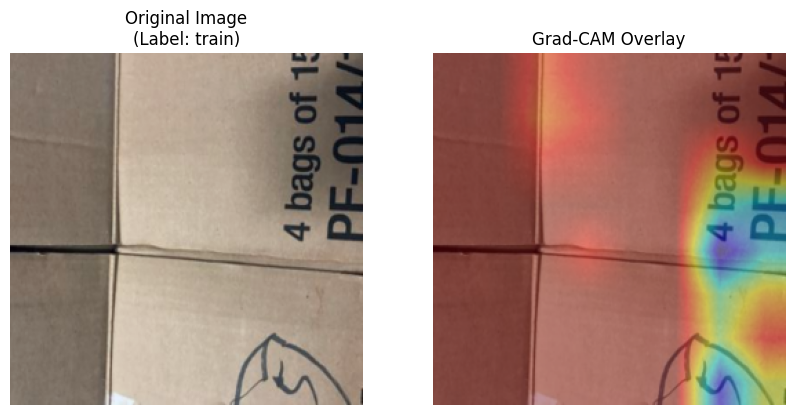

In [22]:
# Example usage on one batch from test_loader
images, labels = next(iter(test_loader))
sample_img = images[0]
sample_label = labels[0].item()
show_gradcam(model, sample_img, sample_label, class_names)


In [23]:
def flatten_4d_to_2d(images_np):
    """
    images_np shape: (N, C, H, W)
    returns flattened shape: (N, C*H*W)
    """
    N, C, H, W = images_np.shape
    return images_np.reshape(N, C*H*W)

def unflatten_2d_to_4d(shap_values_2d, N, C, H, W):
    """
    shap_values_2d shape: (N, C*H*W)
    returns shape: (N, C, H, W)
    """
    return shap_values_2d.reshape(N, C, H, W)


In [24]:
import torch.nn.functional as F

def predict_fn_flat(flat_data_np, model, device, C=3, H=256, W=256):
    """
    flat_data_np: shape (N, C*H*W)
    We unflatten -> (N, C, H, W), run model, return probabilities as numpy array.
    """
    N = flat_data_np.shape[0]
    # Unflatten
    images_4d = flat_data_np.reshape(N, C, H, W)

    # Convert to torch tensor on device
    with torch.no_grad():
        images_t = torch.tensor(images_4d, dtype=torch.float32).to(device)
        outputs = model(images_t)  # logits, shape [N, num_classes]
        probs = F.softmax(outputs, dim=1)  # convert logits to probabilities
        return probs.cpu().numpy()  # back to numpy


In [25]:
!pip install shap


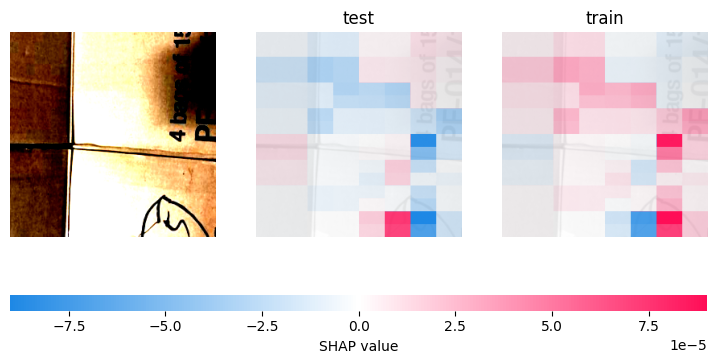

In [29]:
# 1) Build a model prediction wrapper compatible with SHAP's image explainer
def predict_wrapper(images_np):
    # images_np is input as (N, H, W, C)
    # Convert back to (N, C, H, W) PyTorch tensor
    images_t = torch.tensor(images_np.transpose(0, 3, 1, 2), dtype=torch.float32).to(device)
    with torch.no_grad():
        outputs = model(images_t)
        probs = F.softmax(outputs, dim=1)
        return probs.cpu().numpy()

# 2) Get a single test image and convert it to (H, W, C) for the image explainer
test_images, _ = next(iter(test_loader))
single_img_chw = test_images[0].numpy()
single_img_hwc = single_img_chw.transpose(1, 2, 0)

# 3) Initialize SHAP Image Explainer (which uses Partition explainer internally with blur masking)
# This is designed specifically for images and avoids the high-dimensional max_evals issue
masker = shap.maskers.Image("blur(128,128)", shape=(256, 256, 3))
explainer = shap.Explainer(predict_wrapper, masker, output_names=class_names)

# Compute SHAP values with a reasonable budget (e.g., 500 evaluations of blurred regions instead of individual pixels)
shap_values = explainer(np.expand_dims(single_img_hwc, axis=0), max_evals=500, batch_size=50)

# 4) Plot the SHAP values
shap.image_plot(shap_values)